# Load data

Loaded 28605 individual request records
Data columns: ['start_time', 'role', 'duration_ms', 'operation', 'resource', 'is_error']
Time range: 10.0 - 21.0
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 10s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 27,973
    Average Latency: 184.4ms
    Median Latency: 75.0ms
    95th Percentile: 756.4ms
    Standard Deviation: 320.1ms
    Error Rate: 43.11%
    Successful Requests: 15,913
    Failed Requests: 12,060

  Regular Tenant:
    Total Requests: 632
    Average Latency: 165.8ms
    Median Latency: 85.0ms
    95th Percentile: 722.6ms
    Standard Deviation: 298.0ms
    Error Rate: 0.63%
    Successful Requests: 628
    Failed Requests: 4

Baseline Comparison:
  Baseline Latency: 7.0ms
  Current Avg Latency: 165.8ms
  Relative Increase

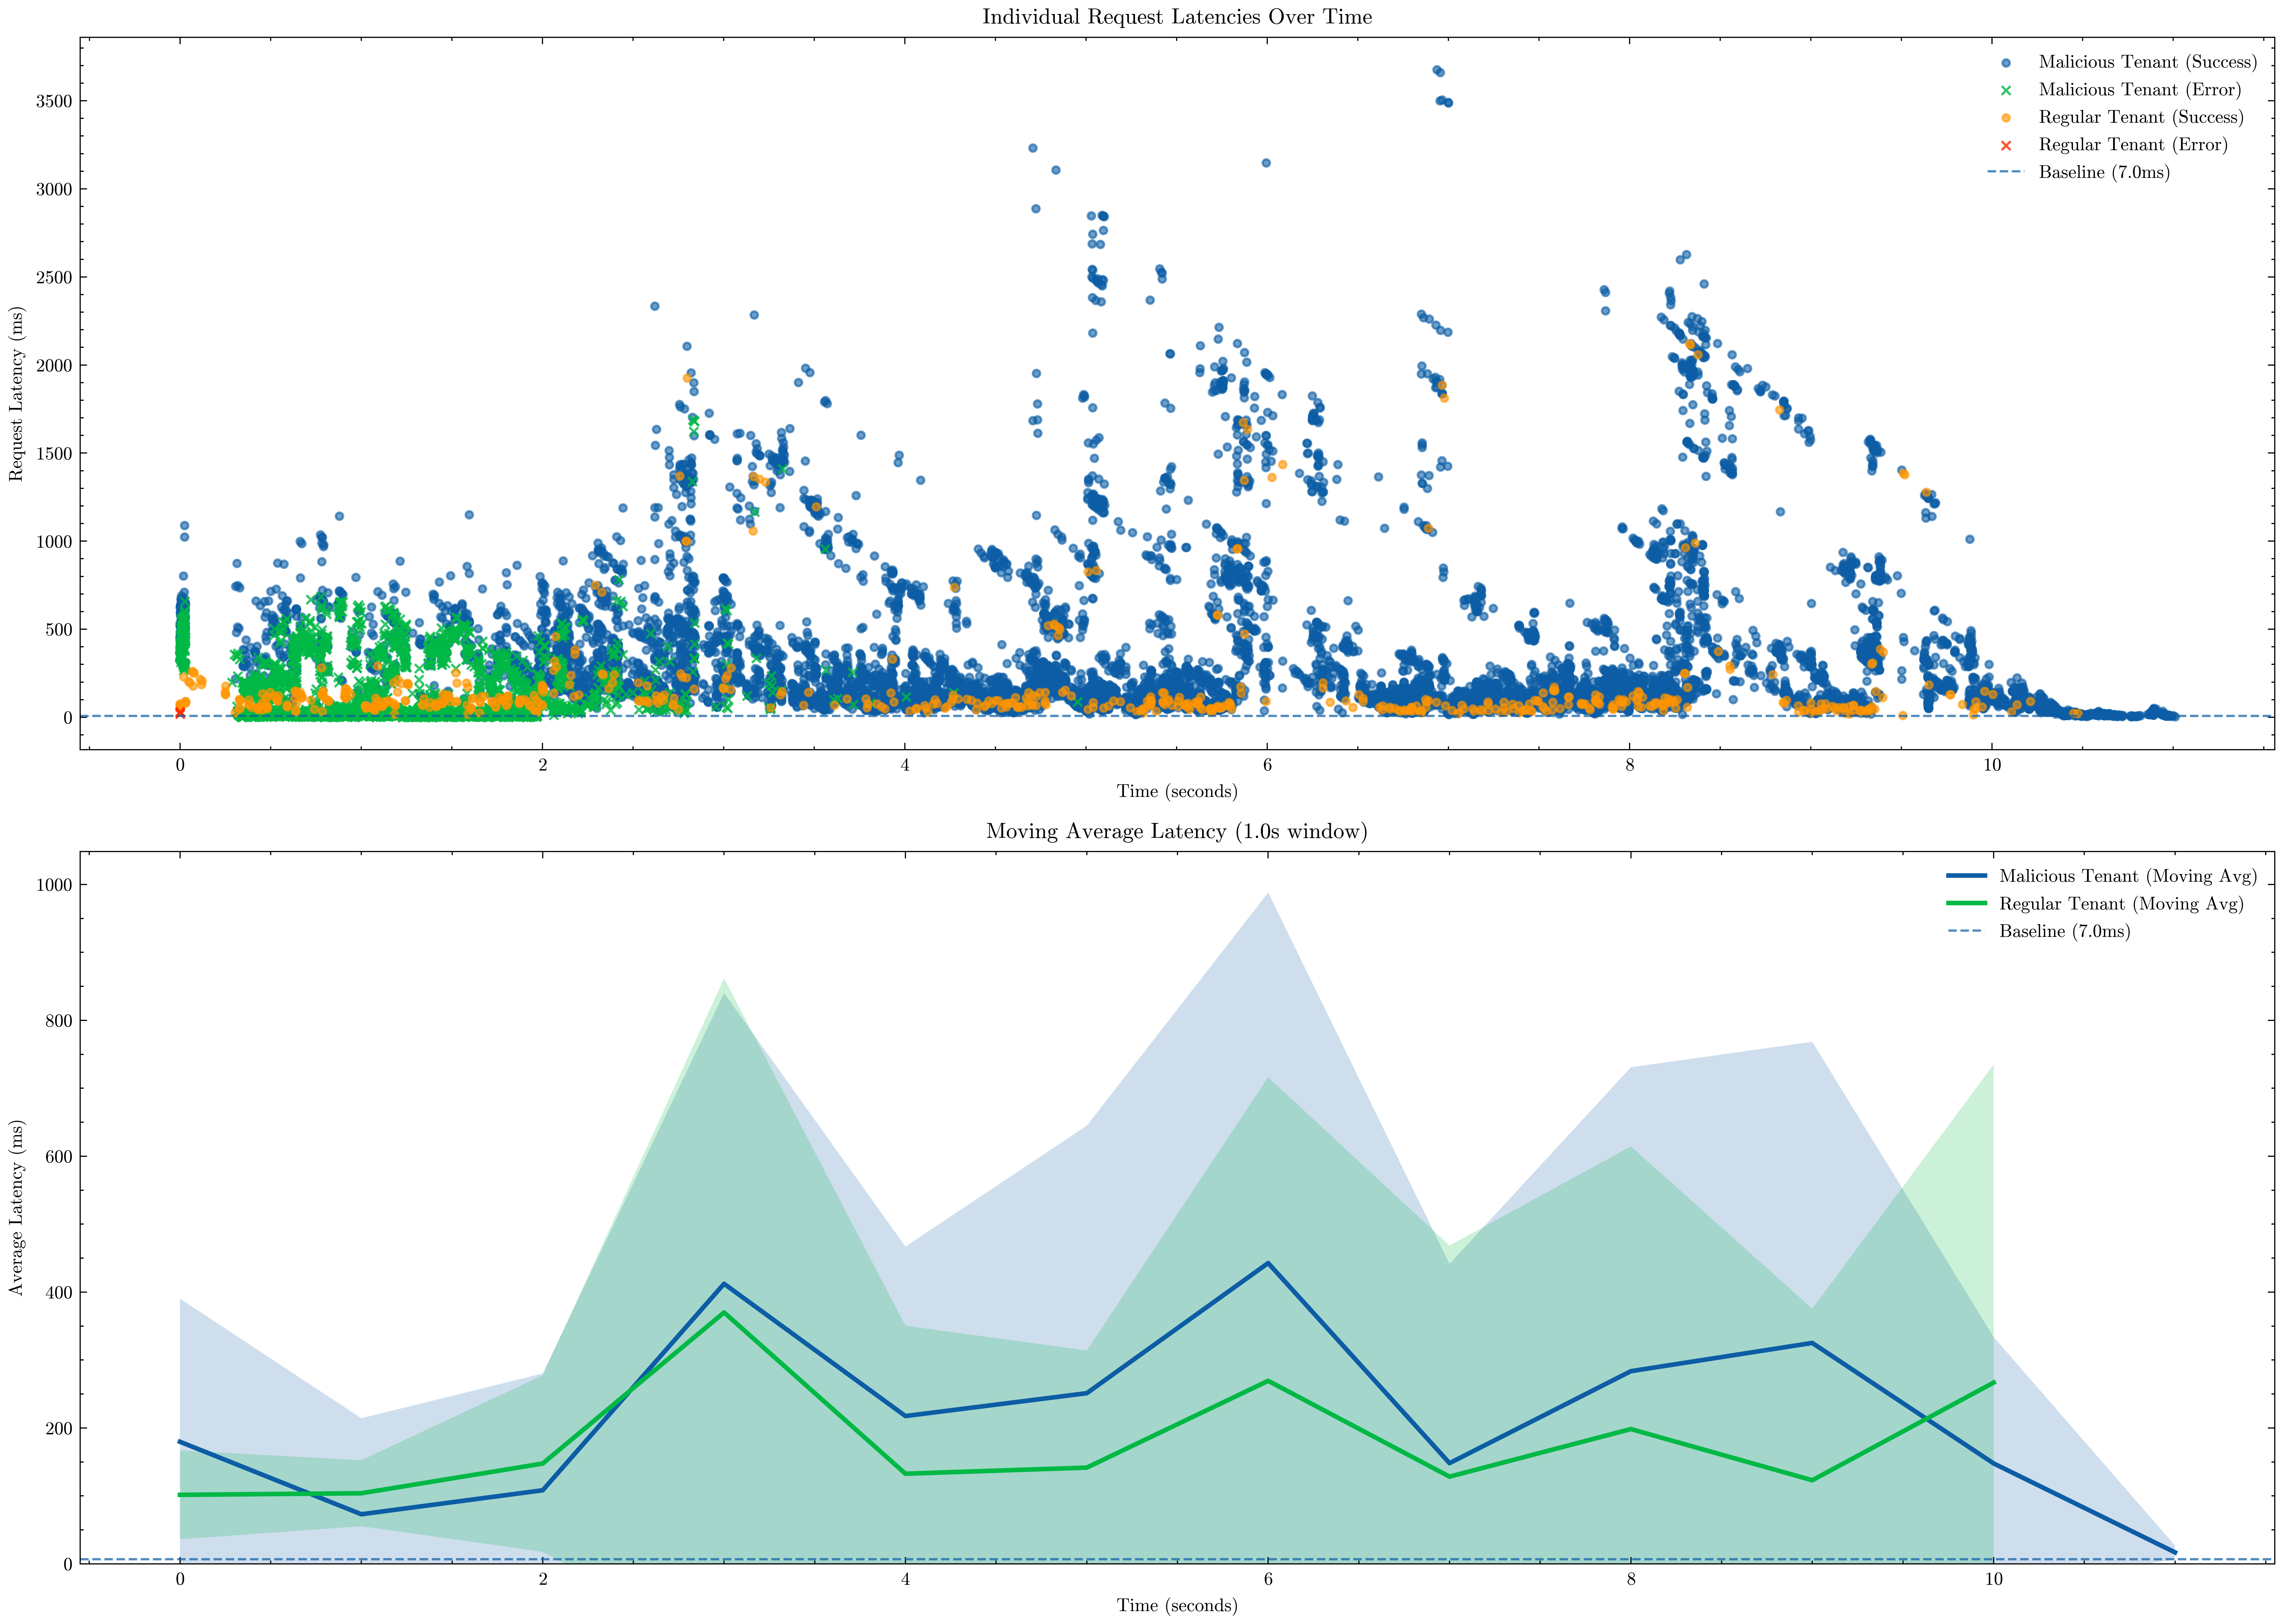

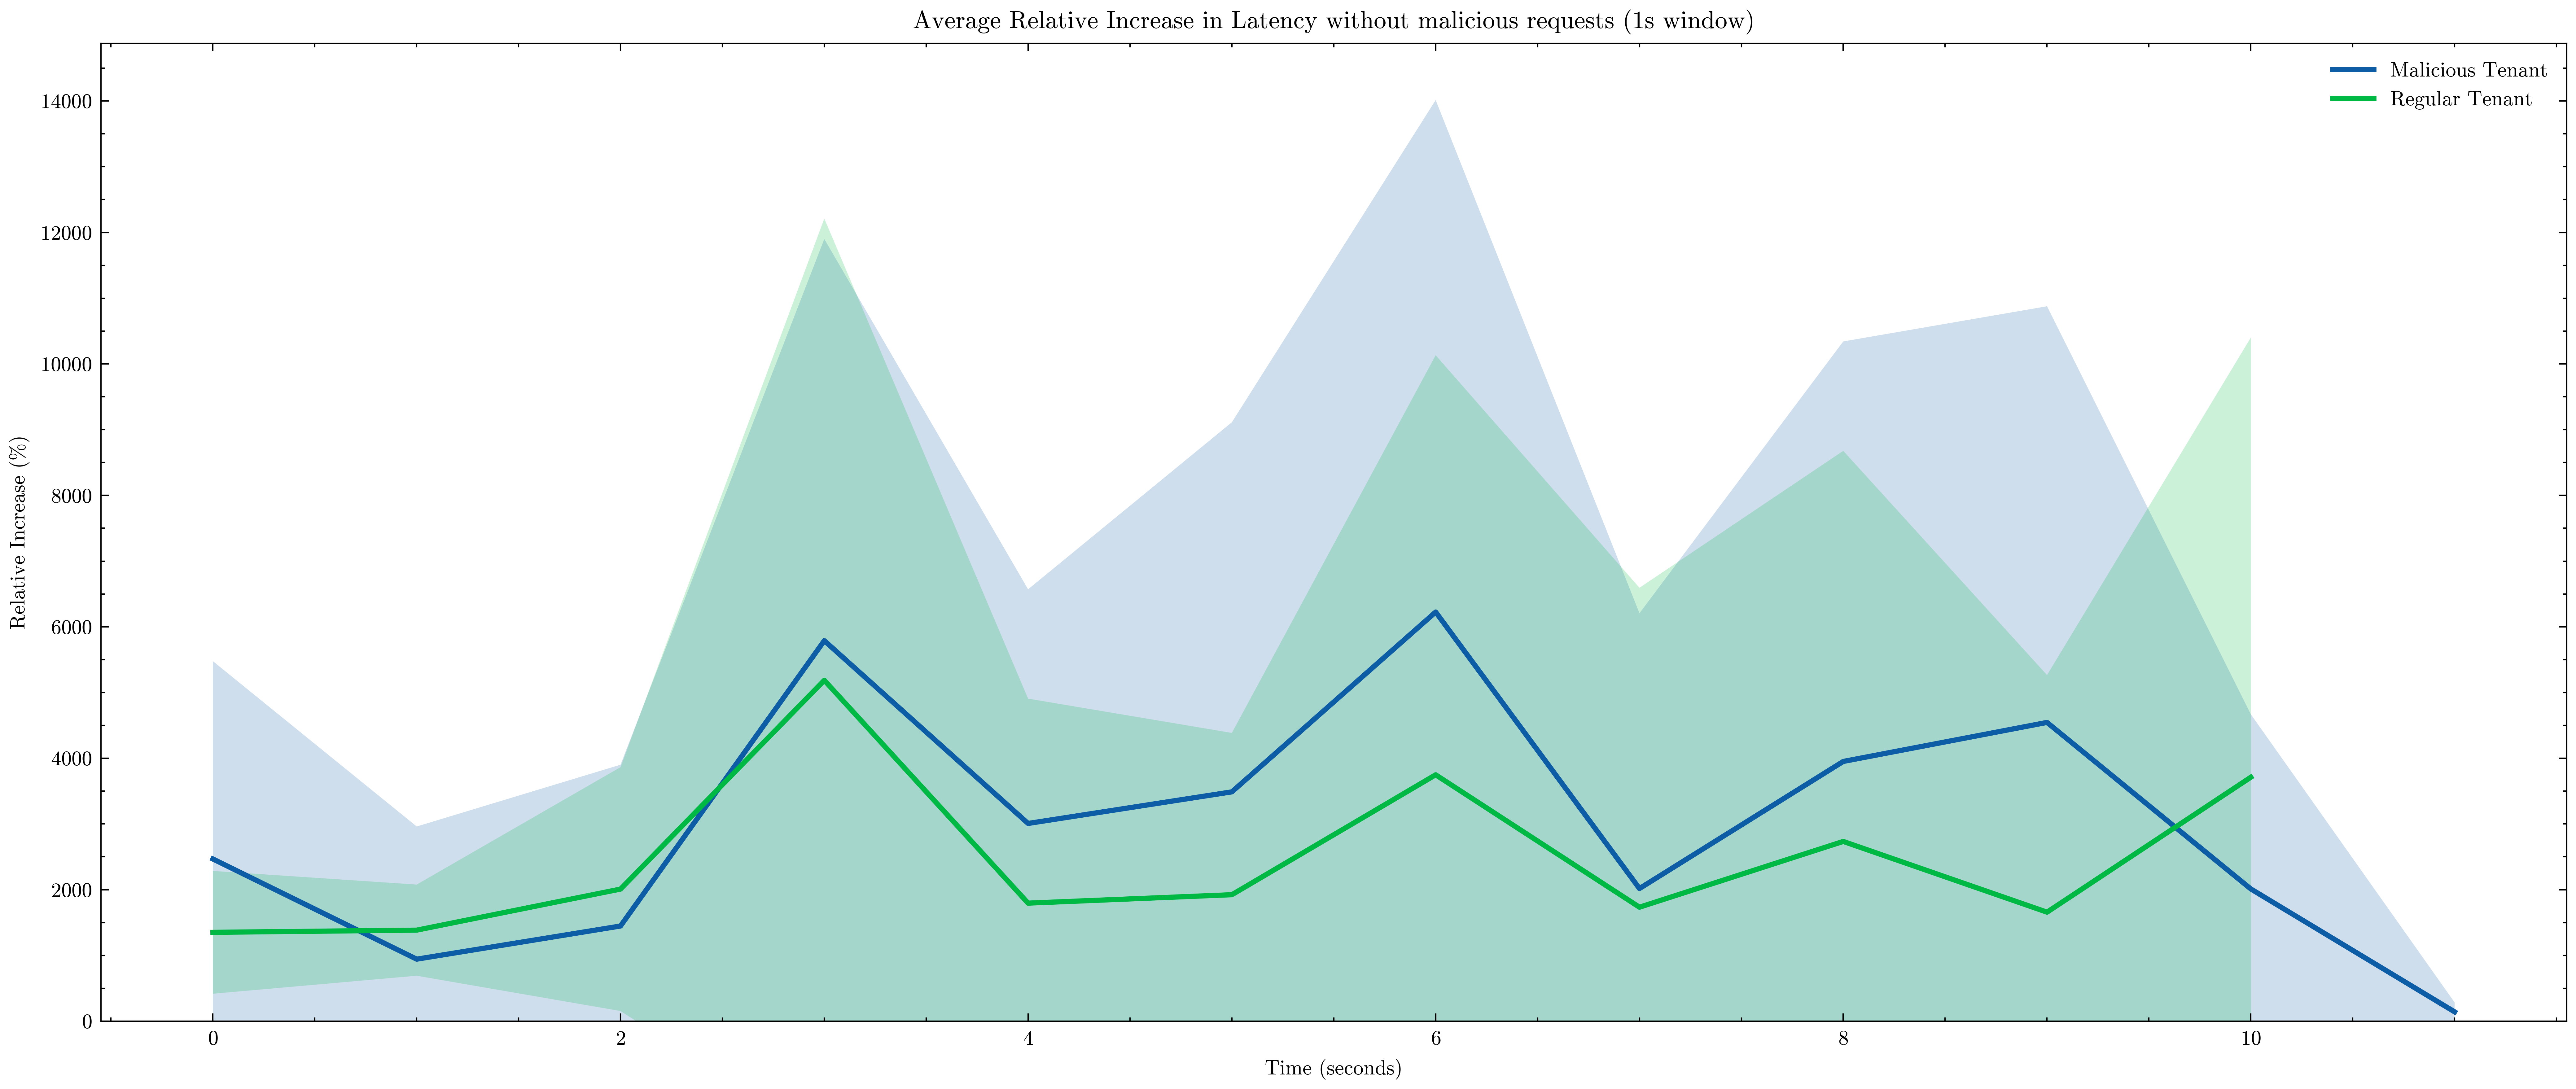


Analysis complete! Plots saved with timestamp: 1749395761
Total individual requests analyzed: 28,605


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns
import numpy as np
import json
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
# plt.style.use('seaborn-v0_8-paper')
# sns.set_palette("muted")

# Set style for paper-like plots
# plt.style.use(['science','ieee','no-latex'])
plt.style.use(['science','no-latex'])

def load_latest_test_data():
    """Load the most recent test data"""
    # Look for both regular and malicious data files
    regular_files = glob.glob("fairness_test_data_regular_*.csv")
    malicious_files = glob.glob("fairness_test_data_malicious_*.csv")
    
    if not regular_files and not malicious_files:
        raise FileNotFoundError("No test data files found")
    
    # Get the latest timestamp
    all_files = regular_files + malicious_files
    latest_file = max(all_files)
    timestamp = latest_file.split('_')[-1].split('.')[0]
    
    # Load both regular and malicious data
    dfs = []
    
    regular_file = f"fairness_test_data_regular_{timestamp}.csv"
    malicious_file = f"fairness_test_data_malicious_{timestamp}.csv"
    
    if glob.glob(regular_file):
        df_regular = pd.read_csv(regular_file)
        dfs.append(df_regular)
    
    if glob.glob(malicious_file):
        df_malicious = pd.read_csv(malicious_file)
        dfs.append(df_malicious)
    
    if not dfs:
        raise FileNotFoundError(f"No data files found for timestamp {timestamp}")
    
    # Combine the dataframes
    df = pd.concat(dfs, ignore_index=True)
    
    # Load metadata
    metadata_file = f"fairness_test_metadata_{timestamp}.json"
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    return df, metadata, timestamp

def preprocess_data(df, metadata):
    """Preprocess the individual request data"""
    # Convert start_time to numeric if it's not already
    df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
    
    # Calculate elapsed seconds from the start of the test
    min_time = df['start_time'].min()
    df['elapsed_seconds'] = df['start_time'] - min_time
    
    # Convert duration from milliseconds to seconds for easier analysis
    df['duration_seconds'] = df['duration_ms'] / 1000.0
    
    # Calculate relative increase from baseline for each request
    baseline_latency = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    df['relative_increase_percent'] = ((df['duration_ms'] - baseline_latency) / baseline_latency) * 100
    
    # Sort by time for proper plotting
    df = df.sort_values(['role', 'elapsed_seconds']).reset_index(drop=True)
    
    return df

def aggregate_data_by_time_window(df, window_size=1.0):
    """Aggregate individual requests into time windows for analysis"""
    aggregated_data = []
    
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        
        # Create time bins
        max_time = role_data['elapsed_seconds'].max()
        time_bins = np.arange(0, max_time + window_size, window_size)
        
        for i in range(len(time_bins) - 1):
            bin_start = time_bins[i]
            bin_end = time_bins[i + 1]
            
            # Find all requests within this time bin
            bin_mask = (role_data['elapsed_seconds'] >= bin_start) & (role_data['elapsed_seconds'] < bin_end)
            bin_data = role_data[bin_mask]
            
            if len(bin_data) > 0:
                # Calculate aggregated metrics for this window
                avg_latency = bin_data['duration_ms'].mean()
                std_latency = bin_data['duration_ms'].std()
                error_rate = bin_data['is_error'].mean()
                total_requests = len(bin_data)
                
                aggregated_data.append({
                    'time_window_start': bin_start,
                    'time_window_end': bin_end,
                    'time_window_center': (bin_start + bin_end) / 2,
                    'role': role,
                    'avg_latency_ms': avg_latency,
                    'std_latency_ms': std_latency,
                    'error_rate': error_rate,
                    'total_requests': total_requests,
                    'requests_per_second': total_requests / window_size
                })
    
    return pd.DataFrame(aggregated_data)

def plot_individual_requests_scatter(df, metadata, timestamp, save_plots=True):
    """Plot individual request latencies as scatter plot"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Individual request latencies
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Use different markers for successful vs failed requests
        success_data = role_data[~role_data['is_error']]
        error_data = role_data[role_data['is_error']]
        
        if len(success_data) > 0:
            ax1.scatter(success_data['elapsed_seconds'], success_data['duration_ms'], 
                       label=f'{role} Tenant (Success)', alpha=0.6, s=10)
        
        if len(error_data) > 0:
            ax1.scatter(error_data['elapsed_seconds'], error_data['duration_ms'], 
                       label=f'{role} Tenant (Error)', alpha=0.8, s=15, marker='x')
    
    # Add baseline line
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Request Latency (ms)')
    ax1.set_title('Individual Request Latencies Over Time')
    ax1.legend()
    
    # Plot 2: Moving average with confidence intervals
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Calculate rolling statistics
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            #if len(window_data) >= 5:  # Only if we have enough data points
            rolling_mean.append(window_data['duration_ms'].mean())
            rolling_std.append(window_data['duration_ms'].std())
            valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax2.plot(valid_time_points, rolling_mean, label=f'{role} Tenant (Moving Avg)', linewidth=2)
            ax2.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax2.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Average Latency (ms)')
    ax2.set_ylim(bottom=0)
    ax2.set_title(f'Moving Average Latency ({window_size}s window)')
    ax2.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'individual_requests_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_relative_increase(df, metadata, timestamp, save_plots=True):
    """Plot relative increase in latency compared to baseline as a moving average"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Calculate rolling average of relative increase
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Sort by elapsed time
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            if len(window_data) >= 3:  # Only if we have enough data points
                rolling_mean.append(window_data['relative_increase_percent'].mean())
                rolling_std.append(window_data['relative_increase_percent'].std())
                valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
            ax.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Relative Increase (%)')
    ax.set_ylim(bottom=0)
    ax.set_title('Average Relative Increase in Latency without malicious requests (1s window)')
    ax.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'relative_increase_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_error_analysis(df, metadata, timestamp, save_plots=True):
    """Plot error analysis for individual requests"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Error rate over time (aggregated by windows)
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax1.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax1.axhline(y=5,  linestyle='--', alpha=0.7, label='Failure Threshold (5%)')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Error Rate (%)')
    ax1.set_title('Error Rate Over Time (1s windows)')
    ax1.legend()
    
    # 2. Error distribution by operation type
    error_by_operation = df.groupby(['role', 'operation'])['is_error'].agg(['count', 'sum', 'mean']).reset_index()
    error_by_operation['error_rate'] = error_by_operation['mean'] * 100
    
    operations = error_by_operation['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(error_by_operation['role'].unique()):
        role_data = error_by_operation[error_by_operation['role'] == role]
        values = [role_data[role_data['operation'] == op]['error_rate'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax2.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax2.set_xlabel('Operation Type')
    ax2.set_ylabel('Error Rate (%)')
    ax2.set_title('Error Rate by Operation Type')
    ax2.set_xticks(x_pos + width / 2)
    ax2.set_xticklabels(operations)
    ax2.legend()
    
    # 3. Latency distribution (box plot)
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(f'{role}\n(n={len(role_data)})')
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_ylabel('Latency (ms)')
    ax3.set_title('Latency Distribution by Role')
    
    # 4. Request throughput over time
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Requests per Second')
    ax4.set_title('Request Throughput Over Time')
    ax4.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'error_analysis_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_summary_dashboard(df, metadata, timestamp, save_plots=True):
    """Create a comprehensive dashboard for individual request data"""
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. Moving average latency (top row, full width)
    ax1 = fig.add_subplot(gs[0, :])
    window_size = 1.0
    for role in df['role'].unique():
        role_data = df[df['role'] == role].sort_values('elapsed_seconds')
        if len(role_data) == 0:
            continue
        
        # Calculate rolling average
        max_time = role_data['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)
        rolling_mean = []
        valid_time_points = []
        
        for t in time_points:
            window_mask = (role_data['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data[window_mask]
            
            if len(window_data) >= 3:
                rolling_mean.append(window_data['duration_ms'].mean())
                valid_time_points.append(t)
        
        if rolling_mean:
            ax1.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
    
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax1.set_title('Average Request Latency Over Time')
    ax1.set_ylabel('Latency (ms)')
    ax1.legend()
    
    # 2. Error rates (second row, left)
    ax2 = fig.add_subplot(gs[1, 0])
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax2.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role}', marker='o', markersize=3)
    ax2.axhline(y=5,  linestyle='--', alpha=0.7, label='Threshold')
    ax2.set_title('Error Rate Over Time')
    ax2.set_ylabel('Error Rate (%)')
    ax2.legend()
    
    # 3. Latency distribution (second row, middle)
    ax3 = fig.add_subplot(gs[1, 1])
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(role)
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_title('Latency Distribution')
    ax3.set_ylabel('Latency (ms)')
    
    # 4. Request throughput (second row, right)
    ax4 = fig.add_subplot(gs[1, 2])
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role}', marker='o', markersize=3)
    ax4.set_title('Throughput Over Time')
    ax4.set_ylabel('Requests/sec')
    ax4.legend()
    
    # 5. Operation type analysis (third row, left and middle)
    ax5 = fig.add_subplot(gs[2, :2])
    operation_stats = df.groupby(['role', 'operation']).agg({
        'duration_ms': ['count', 'mean', 'std'],
        'is_error': 'mean'
    }).round(2)
    
    # Flatten column names
    operation_stats.columns = ['_'.join(col).strip() for col in operation_stats.columns]
    operation_stats = operation_stats.reset_index()
    
    # Create a grouped bar chart for average latency by operation
    operations = operation_stats['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(operation_stats['role'].unique()):
        role_data = operation_stats[operation_stats['role'] == role]
        values = [role_data[role_data['operation'] == op]['duration_ms_mean'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax5.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax5.set_title('Average Latency by Operation Type')
    ax5.set_ylabel('Average Latency (ms)')
    ax5.set_xticks(x_pos + width / 2)
    ax5.set_xticklabels(operations)
    ax5.legend()
    
    # 6. Resource type analysis (third row, right)
    ax6 = fig.add_subplot(gs[2, 2])
    resource_stats = df.groupby(['role', 'resource']).agg({
        'duration_ms': 'mean',
        'is_error': 'mean'
    }).reset_index()
    
    resources = resource_stats['resource'].unique()
    x_pos = np.arange(len(resources))
    
    for i, role in enumerate(resource_stats['role'].unique()):
        role_data = resource_stats[resource_stats['role'] == role]
        values = [role_data[role_data['resource'] == res]['duration_ms'].iloc[0] 
                 if len(role_data[role_data['resource'] == res]) > 0 else 0 
                 for res in resources]
        ax6.bar(x_pos + i * width, values, width, label=f'{role}')
    
    ax6.set_title('Avg Latency by Resource')
    ax6.set_ylabel('Latency (ms)')
    ax6.set_xticks(x_pos + width / 2)
    ax6.set_xticklabels(resources)
    ax6.legend()
    
    # 7. Summary statistics table (bottom row)
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    summary_data = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
            
        avg_latency = role_data['duration_ms'].mean()
        median_latency = role_data['duration_ms'].median()
        p95_latency = role_data['duration_ms'].quantile(0.95)
        std_latency = role_data['duration_ms'].std()
        error_rate = role_data['is_error'].mean()
        total_requests = len(role_data)
        
        summary_data.append([
            role,
            f"{total_requests:,}",
            f"{avg_latency:.1f}ms",
            f"{median_latency:.1f}ms", 
            f"{p95_latency:.1f}ms",
            f"{std_latency:.1f}ms",
            f"{error_rate * 100:.2f}%"
        ])
    
    if summary_data:
        table = ax7.table(cellText=summary_data,
                          colLabels=['Tenant', 'Total Requests', 'Avg Latency', 
                                   'Median Latency', 'P95 Latency', 'Std Dev', 'Error Rate'],
                          cellLoc='center',
                          loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
    ax7.set_title('Individual Request Statistics Summary', pad=20)
    
    # Add test result
    test_result = "PASSED" if metadata.get('test_passed', False) else "FAILED"
    fig.suptitle(f'Fairness Test Analysis - Individual Requests - {test_result}', 
                 fontsize=16, fontweight='bold')
    
    if save_plots:
        plt.savefig(f'individual_requests_dashboard_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_test_summary(df, metadata):
    """Print a detailed test summary for individual request data"""
    print("=" * 70)
    print("FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS")
    print("=" * 70)
    
    config = metadata.get('test_config', {})
    baseline = metadata.get('baseline_metrics', {})
    final = metadata.get('final_results', {})
    
    print(f"Test Result: {'✅ PASSED' if metadata.get('test_passed', False) else '❌ FAILED'}")
    print()
    
    print("Test Configuration:")
    print(f"  Regular Requesters: {config.get('regular_requesters', 'N/A')}")
    print(f"  Malicious Requesters: {config.get('malicious_requesters', 'N/A')}")
    print(f"  Regular Request Rate: {config.get('regular_request_rate', 'N/A')}/s")
    print(f"  Malicious Request Rate: {config.get('malicious_request_rate', 'N/A')}/s")
    print(f"  Test Duration: {config.get('test_duration', {}).get('secs', 'N/A')}s")
    print()
    
    print("Individual Request Statistics:")
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        print(f"\n  {role} Tenant:")
        print(f"    Total Requests: {len(role_data):,}")
        print(f"    Average Latency: {role_data['duration_ms'].mean():.1f}ms")
        print(f"    Median Latency: {role_data['duration_ms'].median():.1f}ms")
        print(f"    95th Percentile: {role_data['duration_ms'].quantile(0.95):.1f}ms")
        print(f"    Standard Deviation: {role_data['duration_ms'].std():.1f}ms")
        print(f"    Error Rate: {role_data['is_error'].mean() * 100:.2f}%")
        print(f"    Successful Requests: {(~role_data['is_error']).sum():,}")
        print(f"    Failed Requests: {role_data['is_error'].sum():,}")
    
    print(f"\nBaseline Comparison:")
    baseline_latency = baseline.get('tenant1_avg_latency_ms', 0)
    regular_data = df[df['role'] == 'Regular']
    if len(regular_data) > 0:
        current_avg = regular_data['duration_ms'].mean()
        increase = ((current_avg - baseline_latency) / baseline_latency * 100) if baseline_latency > 0 else 0
        print(f"  Baseline Latency: {baseline_latency:.1f}ms")
        print(f"  Current Avg Latency: {current_avg:.1f}ms")
        print(f"  Relative Increase: {increase:.1f}%")

# Main analysis function
def analyze_fairness_test():
    """Run complete analysis for individual request data"""
    try:
        df, metadata, timestamp = load_latest_test_data()
        
        print(f"Loaded {len(df)} individual request records")
        print(f"Data columns: {list(df.columns)}")
        print(f"Time range: {df['start_time'].min():.1f} - {df['start_time'].max():.1f}")
        
        # Preprocess the data
        df = preprocess_data(df, metadata)
        
        print_test_summary(df, metadata)
        print("\nGenerating plots...")
        
        plot_individual_requests_scatter(df, metadata, timestamp)
        plot_relative_increase(df, metadata, timestamp)
        plot_error_analysis(df, metadata, timestamp)
        plot_summary_dashboard(df, metadata, timestamp)
        
        print(f"\nAnalysis complete! Plots saved with timestamp: {timestamp}")
        print(f"Total individual requests analyzed: {len(df):,}")
        
        return df, metadata
        
    except Exception as e:
        print(f"Error during analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Run the analysis
df, metadata = analyze_fairness_test()